In [1]:
# import dependencies
%matplotlib inline
import os
import sys
import spatioev as se
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scimap
import scimap as sm

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [3]:
adata = se.load_h5ad("data/exp_1.h5ad")
adata

AnnData object with n_obs × n_vars = 51932 × 25
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractal_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11c_nuclear', 'CD14_nuclear', 'CD146_nuclear', 'CD19_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD4_nuclear', 'CD45_nuclear', 'CD68_nuclear', 'CD90_nuclear', 'CK19_nuclear', 'COL1A1_nuclear', 'COL4A1_nuclear', 'COL6A1_nuclear', 'FN_nuclear', 'HLADR_nuclear', 'IGFBP5_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDPN_nuclear', 'RS6_nuclear', 'SMA_nuclear', 'Tenascin_nuclear', 'Vimentin_nuclear', 'dapi_nuclear', 'label_nuclear', 'area_nuclear', 'eccentricity_nuclear', 'major_axis_length_nuclear', 'min

In [4]:
# 1) Read annotations CSV (saved from adata_final.obs.to_csv, so index is first column)
ann = pd.read_csv("results/svm_phenotyping_results.csv", index_col=0)

# 2) Optional: keep only columns you want
ann = ann[["annotated_clusters_update3", "svm_prediction"]]

# 3) Join into adata.obs by cell ID (index)
adata.obs = adata.obs.join(ann, how="left")

In [5]:
se.spatial.estimate_density_adaptive_dbscan_params(adata, 
                                                   label_key="annotated_clusters_update3", 
                                                   label_value="tumour")

,imageid,n_cells,knn_k,knn_distance_median,knn_distance_quantile,eps,min_samples
0,exp,25827,5,37.650204,44.090448,44.090448,10


In [6]:
adata  = se.spatial.cluster_spatial_niches(adata,
                                  label_key="annotated_clusters_update3",
                                  label_value="tumour",
                                  eps=45,
                                  min_samples=5,)

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'tumour_component'}, xlabel='X_centroid', ylabel='Y_centroid'>)

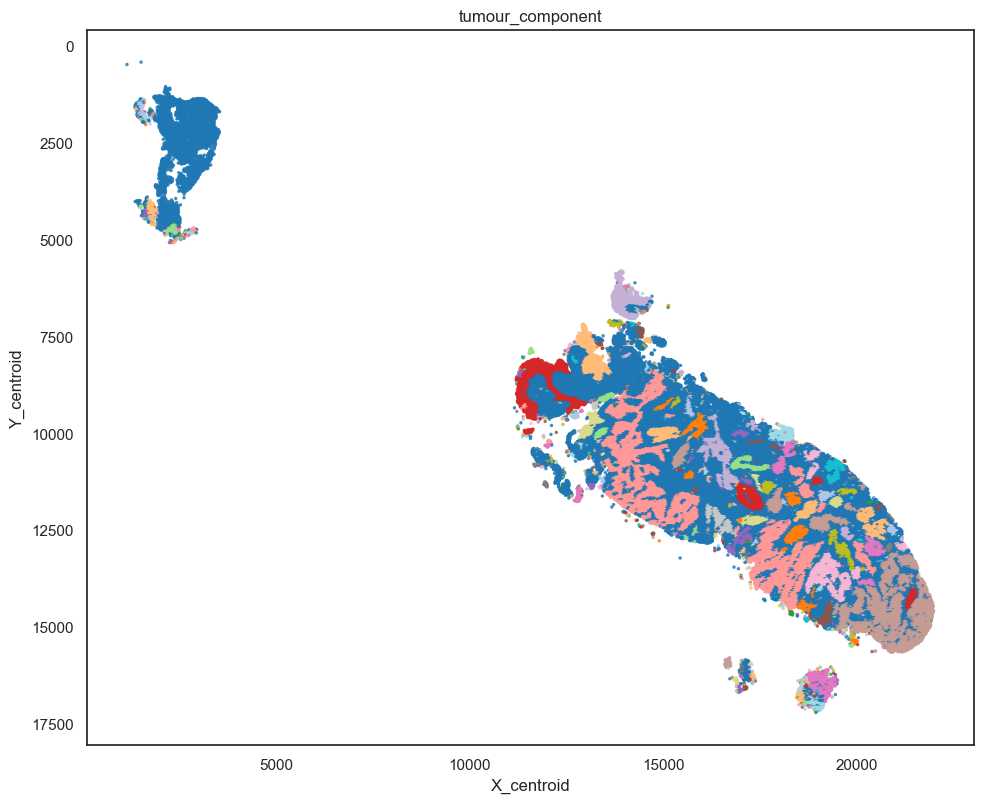

In [7]:
se.plot_spatial_category(
    adata,
    feature="tumour_component",
    image_id=None,          # or one image id like "exp"
    image_key="imageid",
    x_key="X_centroid",
    y_key="Y_centroid",
    point_size=6,
    alpha=0.85,
    palette="tab20",
    show_legend=False,      # important for long component lists
    figsize=(10, 10),
)


In [8]:
# Build tumour niche boundaries
#
# Parameter tuning notes for method="density_mask":
# mask_resolution: smaller -> more detailed but can fragment the geometry
#                   larger  -> smoother / coarser boundary
# mask_sigma:      smaller -> preserves fissures and sharp local detail
#                   larger  -> makes the nest more solid and merges nearby gaps
# mask_threshold:  smaller -> larger / more inclusive nest region
#                   larger  -> tighter / more conservative boundary
# mask_closing_size: smaller -> keeps fine structure
#                    larger  -> fills small gaps and connects nearby fragments
#
# Practical guide:
# if the boundary is too fragmented: increase mask_sigma or mask_closing_size
# if the boundary is too smooth: decrease mask_sigma or mask_closing_size
# if shrinking fails later: the geometry is still too thin / fragmented locally
#
boundary_df = se.spatial.build_niche_boundaries(
    adata,
    component_key="tumour_component",
    min_cluster_size=20,
    method="density_mask",
    mask_resolution=6.0,
    mask_sigma=2.0,
    mask_threshold=0.08,
    mask_closing_size=9,
)

buffered_boundary_df = se.spatial.buffer_niche_boundaries(
    boundary_df,
    component_key="tumour_component",
    expand_by=30 / 0.325,
    shrink_by=30 / 0.325,
)

assignments_df = se.spatial.assign_cells_to_niche_regions(
    adata,
    buffered_boundary_df,
    component_key="tumour_component",
    image_key="imageid",
    x_key="X_centroid",
    y_key="Y_centroid",
    region_key="tumour_region",
    mode="distance_to_edge",
    boundary_width=30 / 0.325,
)


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Niche boundaries: exp'}, xlabel='X_centroid', ylabel='Y_centroid'>)

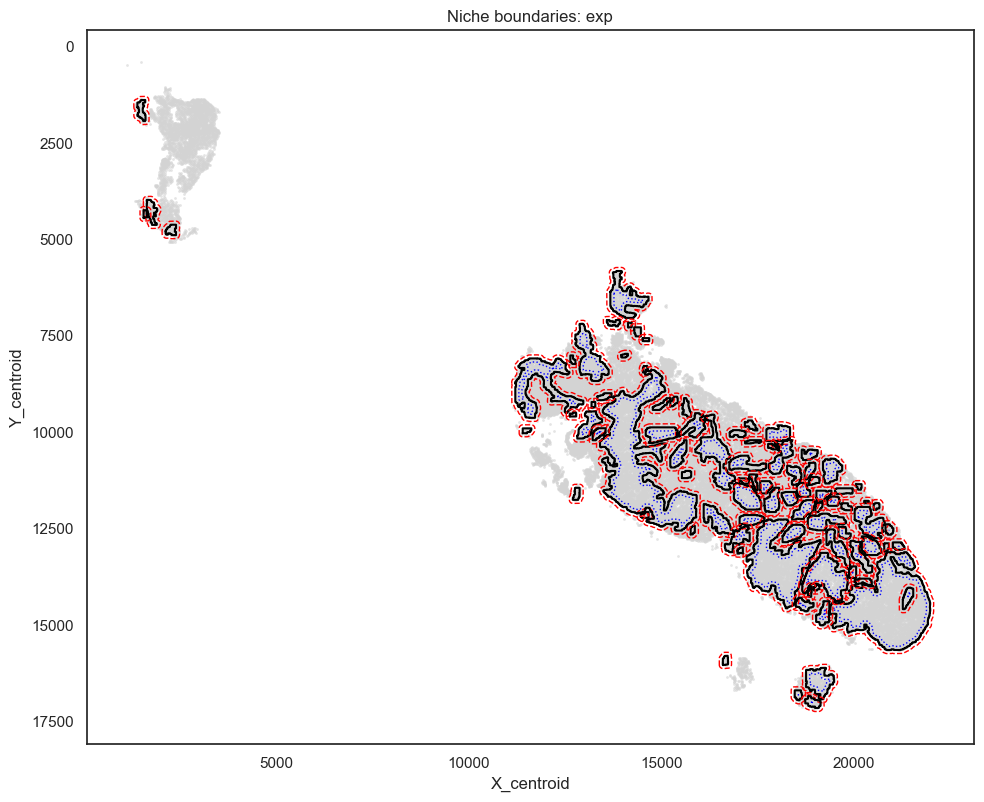

In [9]:
se.plot_niche_boundaries(
    adata,
    buffered_boundary_df,
    image_id="exp",
    image_key="imageid",
    x_key="X_centroid",
    y_key="Y_centroid",
    point_size=4,
    point_color="lightgray",
    point_alpha=0.6,
    boundary_color="black",
    expanded_color="red",
    shrunk_color="blue",
    figsize=(10, 10),
)


In [11]:
adata = se.add_niche_regions_to_obs(
    adata,
    assignments_df,
    region_key="tumour_region",
    component_key="tumour_component",
)


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'tumour_region | exp'}, xlabel='X_centroid', ylabel='Y_centroid'>)

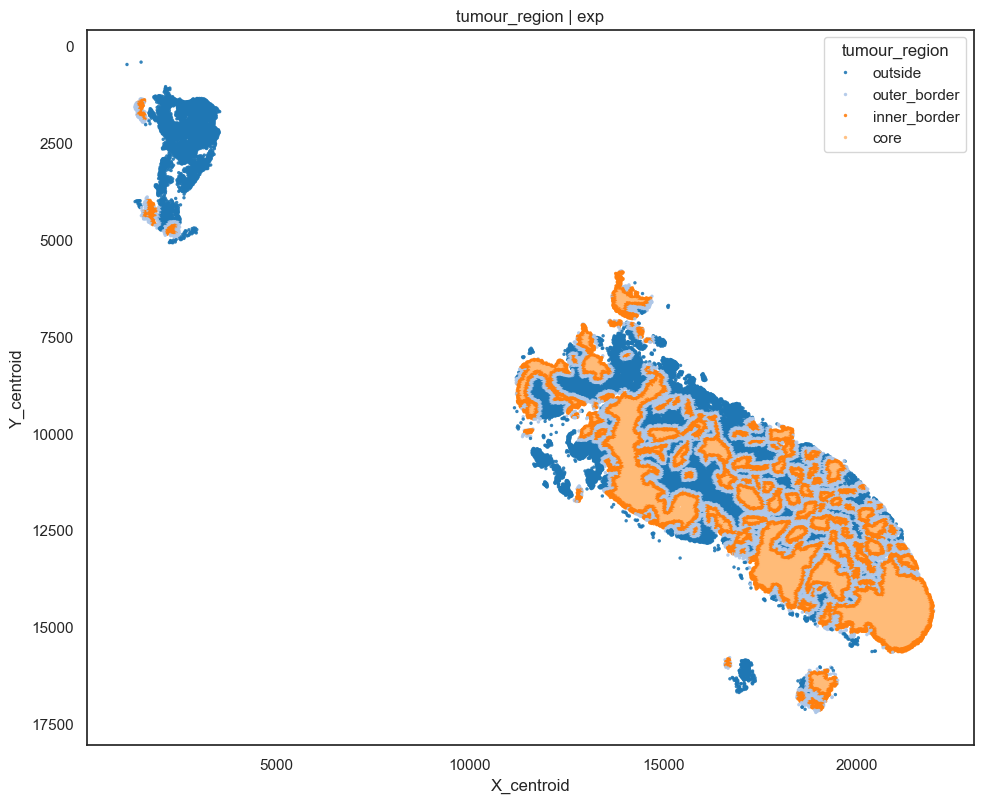

In [12]:
se.plot_spatial_category(
    adata,
    feature="tumour_region",
    image_id="exp",
    image_key="imageid",
    x_key="X_centroid",
    y_key="Y_centroid",
    point_size=6,
    alpha=0.9,
    palette="tab20",
    show_legend=True,
    figsize=(10, 10),
)
